# 숙제 2

데이터과학 입문

원중호 (서울대학교 통계학과)  
May 2026

## 지시사항

제출마감 2026-05-15 23:00

1.  R과 Python을 모두 사용하여 사용된 코드와 데이터랭글링 절차,
    분석결과를 설명한다. 두 언어의 분석결과가 차이가 있으면 그 이유를
    설명한다.
2.  [Quarto
    Markdown](https://quarto.org/docs/authoring/markdown-basics.html)을
    사용한다. 제공된 숙제 `.qmd` 파일에 본인의 답안을 “답안” 절에
    추가하여 제출한다. Quarto Markdown은 RStudio 또는 Visual Studio
    Code에 [Quarto
    Extension](https://marketplace.visualstudio.com/items?itemName=quarto.quarto)을
    추가하여 컴파일, 다른 문서 형식으로 변환할 수 있다.
3.  R의 `reticulate` 패키지를 사용하면 하나의 `.qmd` 파일 안에서 R과
    Python을 동시에 사용할 수 있다. 이때 다음 문법을 사용하여 두 언어
    코드를 탭으로 구분한다. 숙제 `.qmd` 파일은 `reticulate`을 사용하도록
    준비되어 있다.

```` markdown
::: {.panel-tabset}

## R

```{r}
R code
```

## Python

```{python}
Python code
```

:::
````

1.  `.qmd`를 컴파일하여 생성된 `.html` 파일을 함께 저장소에 제출한다.
2.  함께 제공된 `student.yml`을 함께 작성하여 저장소에 제출한다.

## 평가 기준

1.  재현성: 제출된 저장소의 `.qmd` 파일을 컴파일하여 함께 제출된 `.html`
    파일과 동일한 결과가 나와야 한다.
2.  분석의 정확성: 분석은 올바른 기술적 세부 사항을 포함하여 수행되어야
    한다.
3.  보고서의 전반적인 품질: 데이터 가공 및 분석 결과가 명확하고 자세하게
    설명되어야 한다.
4.  코드의 전반적인 품질: 코드는 체계적으로 정리되어 있어야 하며,
    가독성을 높이기 위해 적절한 주석이 포함되어야 한다.

#### **늦게 제출된 과제물은 받지 않는다.**

# 1부 교과서 연습문제

## 문제 1-1

1.  MDSR 6장 연습문제 6.6.9

2.  MDSR 6장 연습문제 6.6.10

### 답안

## R

``` r
# 6.6.9.
library(tidyverse)
library(babynames)

glimpse(babynames)
```

    Rows: 1,924,665
    Columns: 5
    $ year <dbl> 1880, 1880, 1880, 1880, 1880, 1880, 1880, 1880, 1880, 1880, 1880,…
    $ sex  <chr> "F", "F", "F", "F", "F", "F", "F", "F", "F", "F", "F", "F", "F", …
    $ name <chr> "Mary", "Anna", "Emma", "Elizabeth", "Minnie", "Margaret", "Ida",…
    $ n    <int> 7065, 2604, 2003, 1939, 1746, 1578, 1472, 1414, 1320, 1288, 1258,…
    $ prop <dbl> 0.07238359, 0.02667896, 0.02052149, 0.01986579, 0.01788843, 0.016…

``` r
mdsr::make_babynames_dist 
```

    function () 
    {
        actuarial <- dplyr::select(dplyr::filter(dplyr::mutate(babynames::lifetables, 
            age_today = x, alive_prob = lx/1e+05, more_years = ex, 
            life_exp = x + ex), year + x == 2014), year, sex, age_today, 
            alive_prob, life_exp)
        years <- min(actuarial$year):max(actuarial$year)
        men <- approximate(dplyr::filter(actuarial, sex == "M"), 
            years = years)
        women <- approximate(dplyr::filter(actuarial, sex == "F"), 
            years = years)
        actuarial_interp <- dplyr::bind_rows(men, women)
        actuarial_interp <- dplyr::mutate(dplyr::rename(actuarial_interp, 
            year = x, alive_prob = y), sex = c(rep("M", length(years)), 
            rep("F", length(years))))
        BabynameDist <- dplyr::mutate(dplyr::inner_join(babynames::babynames, 
            actuarial_interp, by = c("year", "sex")), count_thousands = n/1000, 
            age_today = 2014 - year, est_alive_today = n * alive_prob)
    }
    <bytecode: 0x00000198b3db57a8>
    <environment: namespace:mdsr>

``` r
# 문제 : 각 이름을 가진 사람들이 2014년에 몇 명 정도 살아 있을지 추정한 열을 기존 tibble에 추가하는 것

# 1. lifetables 자료 정리
actuarial <- lifetables %>%
  mutate(
    age_today = x,
    alive_prob = lx / 100000,      # lx = 10만 명 기준 x세까지 산 사람 수 
    more_years = ex,               # ex = 앞으로 더 살 것으로 기대되는 평균 연수 
    life_exp = x + ex              # 총 기대수명 
  ) %>%
  filter(year + x == 2014) %>%     # 태어난 연도 + 나이 == 2014인 데이터만 추출 
  select(year, sex, age_today, alive_prob, life_exp)

# 2. 연도 범위 만들기
years <- min(actuarial$year):max(actuarial$year)

# 생존확률 자료가 모든 출생연도별로 있지 않고 10년 단위로 존재한다. 
# 따라서 이를 연속으로 만들기 위해 선형보간 함수를 사용한다. 
approximate <- function(data, years) {
  approx(
    x = data$year, # data 내 year에 있는, 보간의 기준점 
    y = data$alive_prob, # 보간 
    xout = years   # 새로 계산하고 싶은 연도 
  ) %>%
    as.data.frame()
}


# 그런데 lifetables 데이터에 sex 열이 따로 있다
# 이는 성별에 따라 생존율이 다르다는 의미이므로 두 범주를 분류하여 계산한다 
men <- actuarial %>%
  filter(sex == "M") %>%
  approximate(years = years)

women <- actuarial %>%
  filter(sex == "F") %>%
  approximate(years = years)

# 4. 보간 결과 합
actuarial_interp <- bind_rows(men, women) %>%
  rename(
    year = x,
    alive_prob = y
  ) %>%
  mutate(
    sex = c(rep("M", length(years)), rep("F", length(years)))
  )

# 5. babynames 자료와 결합
BabynamesDist <- babynames %>%
  inner_join(actuarial_interp, by = c("year", "sex")) %>%
  mutate(
    count_thousands = n / 1000,
    age_today = 2014 - year,
    est_alive_today = n * alive_prob    # 2014년에도 살아있을 확률
  )

head(BabynamesDist)
```

    # A tibble: 6 × 9
       year sex   name          n   prop alive_prob count_thousands age_today
      <dbl> <chr> <chr>     <int>  <dbl>      <dbl>           <dbl>     <dbl>
    1  1900 F     Mary      16706 0.0526          0           16.7        114
    2  1900 F     Helen      6343 0.0200          0            6.34       114
    3  1900 F     Anna       6114 0.0192          0            6.11       114
    4  1900 F     Margaret   5304 0.0167          0            5.30       114
    5  1900 F     Ruth       4765 0.0150          0            4.76       114
    6  1900 F     Elizabeth  4096 0.0129          0            4.10       114
    # ℹ 1 more variable: est_alive_today <dbl>

``` r
# 6.6.10.
library(tidyverse)
library(Lahman)

cubs_hr <- Teams %>%
  filter(teamID == "CHN") %>%
  select(yearID, HR, HRA) %>%
  pivot_longer(
    cols = c(HR, HRA),               # HRA : 허용한 홈런 수 
    names_to = "type",               # HR 과 HRA 를 같은 변수 구조 안에서 비교할 수 있게 만든다 
    values_to = "home_runs"
  )

head(cubs_hr)
```

    # A tibble: 6 × 3
      yearID type  home_runs
       <int> <chr>     <int>
    1   1876 HR            8
    2   1876 HRA           6
    3   1877 HR            0
    4   1877 HRA           7
    5   1878 HR            3
    6   1878 HRA           4

``` r
ggplot(cubs_hr, aes(x = yearID, y = home_runs)) +
  geom_line() +
  facet_wrap(~ type) +
  labs(
    title = "CHN Home Runs: HR vs HR Allowed",
    x = "Year",
    y = "Number of Home Runs"
  )
```

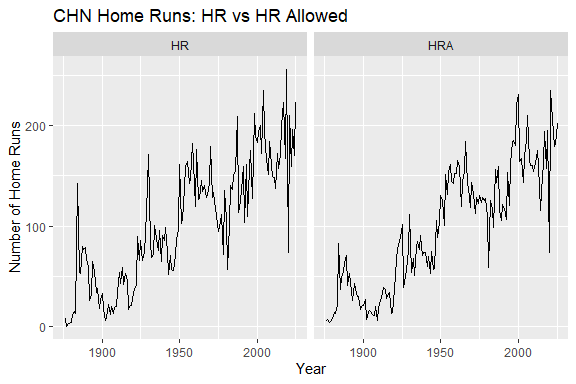

## Python

## 문제 1-2

1.  MDSR 7장 연습문제 7.9.5

2.  MDSR 7장 연습문제 7.9.6

3.  7.7절의 NHANES 분석에서의 `bmi_plot` 및 `map`을 사용한 예제에서
    사용한 다음 코드를 아래와 같이 확장하라.

    ``` r
    c("Age", "HHIncomeMid", "PhysActiveDays", 
      "TVHrsDay", "AlcoholDay", "Pulse") %>%
      map(bmi_plot, .data = NHANES) %>%
      patchwork::wrap_plots(nrow = 2, ncol = 3)
    ```

    - `names()`를 사용하여 76개 변수 모두와 BMI간의 산점도 그리기
    - `across()`를 사용하여 수치형 변수와 BMI간의 산점도 그리기

4.  (보너스 문제) 위의 예제를 `patchworklib` 패키지를 이용해서
    Python으로 옮겨 보아라.

### 답안

## R

``` r
# 7.9.5.
library(tidyverse)
library(NHANES)
library(patchwork)

pulse_plot <- function(.data, x_var) {
  
  plot_data <- .data %>%
    select(Pulse, all_of(x_var)) %>%
    drop_na(Pulse, all_of(x_var))
  
  ggplot(.data, aes(y = Pulse)) +
    aes_string(x = x_var) +
    geom_jitter(alpha = 0.3) +
    geom_smooth(se = FALSE) +
    labs(
      title = paste("Pulse by", x_var),
      subtitle = "NHANES",
      x = x_var,
      y = "Pulse",
    )
}

pulse_vars <- c("Age", "BMI", "TVHrsDay", "BPSysAve")

pulse_vars %>%
  map(pulse_plot, .data = NHANES) %>%
  patchwork::wrap_plots(ncol = 2)
```

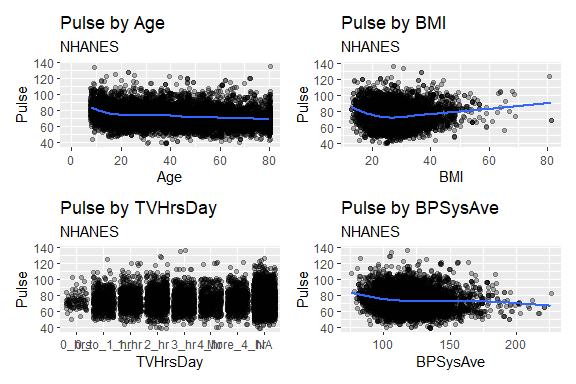

``` r
# Pulse는 Age, BMI, TVHrsDay, BPSysAve와 강한 선형관계를 보이지 않는다.
# 특히 BMI와 TVHrsDay는 관계가 약해 보이며, Age와 BPSysAve도 약한 패턴은 있을 수 있지만 
# 산포가 커서 단독 설명력은 크지 않아 보인다.

# 7.9.6.
library(tidyverse)
library(Lahman)

all_years <- tibble(
  yearID = min(Batting$yearID, na.rm = TRUE):max(Batting$yearID, na.rm = TRUE)
)

player_year_hr <- Batting %>%
  group_by(playerID, yearID) %>%
  summarise(
    HR = sum(HR, na.rm = TRUE),
    .groups = "drop"
  )

career_hr <- player_year_hr %>%
  group_by(playerID) %>%
  group_modify(~ {
    all_years %>%
      left_join(.x, by = "yearID") %>%
      mutate(
        HR = replace_na(HR, 0),
        career_HR = cumsum(HR)
      )
  }) %>%
  ungroup()

player_names <- People %>%
  transmute(
    playerID,
    player = str_squish(paste(nameFirst, nameLast))
  )

record_hr <- career_hr %>%
  group_by(yearID) %>%
  slice_max(career_HR, n = 1, with_ties = FALSE) %>%
  ungroup() %>%
  filter(career_HR > 0) %>%
  left_join(player_names, by = "playerID") %>%
  arrange(yearID) %>%
  mutate(
    holder_change = playerID != lag(playerID, default = "")
  )

record_changes <- record_hr %>%
  filter(holder_change)

ggplot(record_hr, aes(x = yearID, y = career_HR)) +
  geom_step(linewidth = 1) +
  geom_point(
    data = record_changes,
    aes(x = yearID, y = career_HR),
    size = 2
  ) +
  geom_text(
    data = record_changes %>% filter(career_HR >= 100),
    aes(label = player),
    vjust = -0.7,
    size = 3,
    check_overlap = TRUE
  ) +
  labs(
    title = "Progression of the MLB Career Home Run Record",
    subtitle = "Record holder by season, calculated from Lahman Batting data",
    x = "Year",
    y = "Career Home Runs",
    caption = "Source: Lahman package | Variables: playerID, yearID, HR"
  )
```

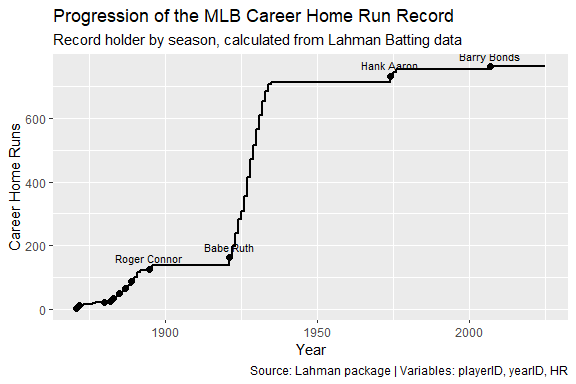

``` r
# 7.7절 확장 
library(tidyverse)
library(NHANES)
library(patchwork)

bmi_plot <- function(.data, x_var) {
  
  d <- .data %>%
    select(BMI, all_of(x_var)) %>%
    filter(
      !is.na(BMI),
      !is.na(.data[[x_var]])
    )
  
  p <- ggplot(d) +
    aes_string(x = x_var, y = "BMI") +
    geom_jitter(alpha = 0.3) +
    labs(
      title = paste("BMI by", x_var),
      subtitle = "NHANES",
      x = x_var,
      y = "BMI",
      caption = "Source: US National Center for Health Statistics (NCHS)"
    )
  
  if (is.numeric(d[[x_var]])) {
    p + geom_smooth(se = FALSE)
  } else {
    p
  }
}

# 1. names()를 사용하여 모든 변수와 BMI 산점도
all_vars <- names(NHANES)

all_vars %>%
  map(bmi_plot, .data = NHANES) %>%
  patchwork::wrap_plots(ncol = 4)
```

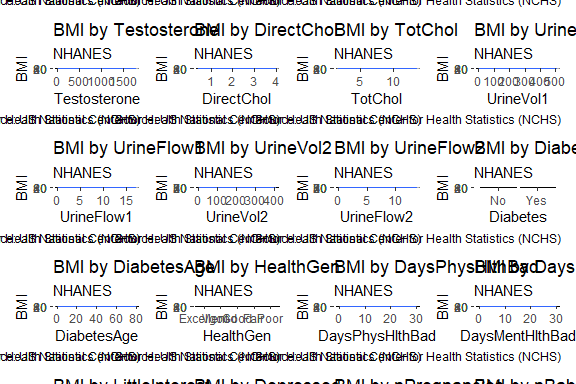

``` r
# 2. across()를 사용하여 수치형 변수와 BMI 산점도
numeric_vars <- NHANES %>%
  summarise(across(where(is.numeric), ~ TRUE)) %>%
  names()

# 76개 중 BMI - BMI 간 비교 그래프는 삭제 
numeric_vars_except_bmi <- numeric_vars %>%
 setdiff("BMI")

numeric_vars_except_bmi %>%
  map(bmi_plot, .data = NHANES) %>%
  patchwork::wrap_plots(ncol = 4)
```

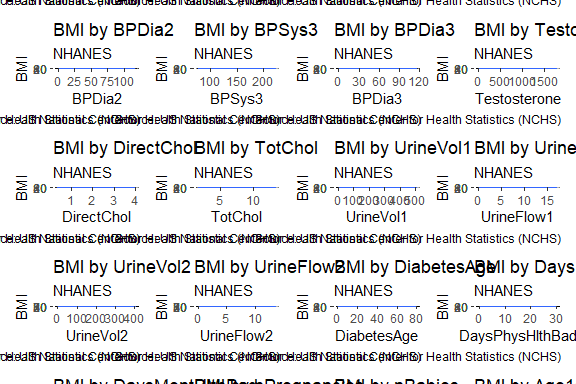

## Python

## 문제 1-3

1.  MDSR 8장 연습문제 8.12.8

2.  MDSR 8장 연습문제 8.12.10

### 답안

## R

# 8.12.8.

충분히 문제가 될 수 있다. 두 데이터가 개인을 특정할 수 있는 이름과
이메일 주소가 그중 가장 중요한 정보들이긴 하지만 화면 이름, 지리적 위치,
IP 주소, 인구통계 정보, 관계 선호 정보 역시 충분히 노출될 경우 위험한
요소들이다. 이러한 데이터들은 다른 공개 자료와 결합하여 특정 개인을
추적하거나 식별하는 데 사용될 수 있기 때문이다. 이외에도 사생활 침해
등의 원치 않는 피해로 이어질 수 있다. 따라서 이 데이터셋은 충분한
익명화라고 보기 어렵다.

``` r
# 8.12.10. 
library(tidyverse)

set.seed(123)

simulate_once <- function(n = 250, p = 100, alpha = 0.05) {
  
  X <- matrix(rnorm(n * p), nrow = n, ncol = p)
  colnames(X) <- paste0("x", 1:p)
  
  y <- rnorm(n)
  
  data <- as_tibble(X) %>%
    mutate(y = y)
  
  p_values <- map_dbl(colnames(X), function(var) {
    
    fit <- lm(reformulate(var, response = "y"), data = data)
    
    coef(summary(fit))[2, "Pr(>|t|)"]
  })
  
  selected_vars <- colnames(X)[p_values < alpha]
  
  if (length(selected_vars) == 0) {
    return(
      tibble(
        num_selected = 0,
        overall_p_value = 1
      )
    )
  }
  
  final_fit <- lm(
    reformulate(selected_vars, response = "y"),
    data = data
  )
  
  f_stat <- summary(final_fit)$fstatistic
  
  overall_p_value <- pf(
    f_stat[1],
    f_stat[2],
    f_stat[3],
    lower.tail = FALSE
  )
  
  tibble(
    num_selected = length(selected_vars),
    overall_p_value = as.numeric(overall_p_value)
  )
}

sim_result <- map_dfr(1:5000, ~ simulate_once())

ggplot(sim_result, aes(x = overall_p_value)) +
  geom_histogram(binwidth = 0.01, boundary = 0) +
  labs(
    title = "Distribution of Overall p-values After Variable Screening",
    subtitle = "Null case: no predictors are truly associated with the outcome",
    x = "Overall model p-value",
    y = "Count",
    caption = "Simulation: n = 250, p = 100, 5000 repetitions"
  )
```

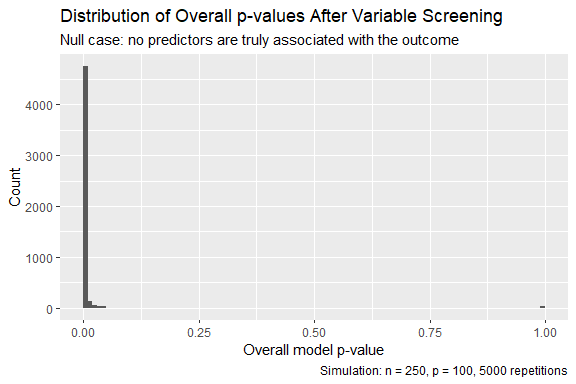

``` r
ggplot(sim_result, aes(x = num_selected)) +
  geom_histogram(binwidth = 1, boundary = 0) +
  labs(
    title = "Number of Predictors Selected by 100 Bivariate Tests",
    subtitle = "Each predictor is tested at alpha = 0.05",
    x = "Number of selected predictors",
    y = "Count"
  )
```

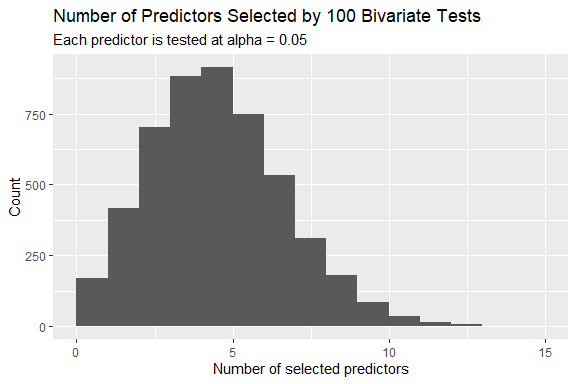

## Python

## 문제 1-4

1.  MDSR 9장 연습문제 9.9.4

2.  MDSR 9장 연습문제 9.9.7

### 답안

## R

``` r
# 9.9.4.
library(tidyverse)
library(NHANES)

set.seed(123)

# 1. 분석용 데이터 만들기
nhanes_female <- NHANES %>%
  filter(str_to_lower(as.character(Gender)) == "female") %>%
  select(Age, BMI, Diabetes) %>%
  filter(
    !is.na(Age),
    !is.na(BMI),
    !is.na(Diabetes)
  ) %>%
  mutate(
    diabetes = if_else(Diabetes == "Yes", 1, 0)
  )

n_sample <- floor(nrow(nhanes_female) / 10)

fit_model <- function(data) {
  glm(
    diabetes ~ Age + BMI,
    data = data,
    family = binomial()
  )
}

model_summary <- function(fit, label) {
  coef_table <- summary(fit)$coefficients
  
  tibble(
    mechanism = label,
    term = rownames(coef_table),
    estimate = coef_table[, "Estimate"],
    std_error = coef_table[, "Std. Error"],
    p_value = coef_table[, "Pr(>|z|)"]
  )
}

# MCAR
mcar_data <- nhanes_female %>%
  slice_sample(n = n_sample)

mcar_fit <- fit_model(mcar_data)

# CDM
cdm_data <- nhanes_female %>%
  mutate(
    observe_prob = 1 / (1 + exp((Age - 45) / 10))
  ) %>%
  slice_sample(
    n = n_sample,
    weight_by = observe_prob
  )

cdm_fit <- fit_model(cdm_data)

# NINR
ninr_data <- nhanes_female %>%
  mutate(
    observe_prob = if_else(diabetes == 1, 0.2, 1)
  ) %>%
  slice_sample(
    n = n_sample,
    weight_by = observe_prob
  )

ninr_fit <- fit_model(ninr_data)

full_fit <- fit_model(nhanes_female)

result_table <- bind_rows(
  model_summary(full_fit, "Full data"),
  model_summary(mcar_fit, "MCAR"),
  model_summary(cdm_fit, "CDM"),
  model_summary(ninr_fit, "NINR")
)

result_table
```

    # A tibble: 12 × 5
       mechanism term        estimate std_error   p_value
       <chr>     <chr>          <dbl>     <dbl>     <dbl>
     1 Full data (Intercept)  -8.21     0.345   1.53e-125
     2 Full data Age           0.0559   0.00358 8.35e- 55
     3 Full data BMI           0.0954   0.00718 2.92e- 40
     4 MCAR      (Intercept)  -8.17     1.07    2.59e- 14
     5 MCAR      Age           0.0540   0.0104  2.10e-  7
     6 MCAR      BMI           0.102    0.0223  4.90e-  6
     7 CDM       (Intercept)  -8.75     1.54    1.36e-  8
     8 CDM       Age           0.0599   0.0221  6.66e-  3
     9 CDM       BMI           0.0966   0.0329  3.31e-  3
    10 NINR      (Intercept) -12.0      2.14    2.37e-  8
    11 NINR      Age           0.0782   0.0222  4.35e-  4
    12 NINR      BMI           0.131    0.0325  5.62e-  5

``` r
simulate_missing <- function(mechanism) {
  
  if (mechanism == "MCAR") {
    
    sampled_data <- nhanes_female %>%
      slice_sample(n = n_sample)
    
  } else if (mechanism == "CDM") {
    
    sampled_data <- nhanes_female %>%
      mutate(
        observe_prob = 1 / (1 + exp((Age - 45) / 10))
      ) %>%
      slice_sample(
        n = n_sample,
        weight_by = observe_prob
      )
    
  } else if (mechanism == "NINR") {
    
    sampled_data <- nhanes_female %>%
      mutate(
        observe_prob = if_else(diabetes == 1, 0.2, 1)
      ) %>%
      slice_sample(
        n = n_sample,
        weight_by = observe_prob
      )
  }
  
  fit <- fit_model(sampled_data)
  
  model_summary(fit, mechanism)
}


sim_result <- map_dfr(
  1:500,
  ~ bind_rows(
    simulate_missing("MCAR"),
    simulate_missing("CDM"),
    simulate_missing("NINR")
  )
)

ggplot(sim_result, aes(x = mechanism, y = estimate)) +
  geom_boxplot() +
  facet_wrap(~ term, scales = "free_y") +
  labs(
    title = "Effect of Missing Data Mechanism on Logistic Regression Estimates",
    subtitle = "Outcome: Diabetes among female NHANES participants",
    x = "Missing data mechanism",
    y = "Coefficient estimate",
    caption = "Source: NHANES package"
  )
```

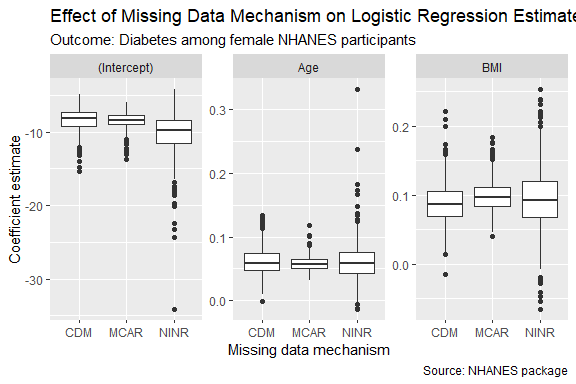

``` r
# MCAR에서는 자료가 무작위로 줄어들기 때문에 표준오차는 커지지만 체계적인 
# 편향은 크지 않을 것으로 예상된다. CDM에서는 나이가 많은 대상자가 덜 관측되므로 
# 나이 분포가 왜곡되고, 특히 고령층에 대한 예측 정확도가 떨어질 수 있다. 
# NINR에서는 결측 여부가 당뇨병 상태 자체에 의존하므로 당뇨 확률 모형이 심각하게 편향될 수 있다.


# 9.9.7.
library(tidyverse)
library(mosaicData)

data(Whickham)

# 데이터 구조 확인
glimpse(Whickham)
```

    Rows: 1,314
    Columns: 3
    $ outcome <fct> Alive, Alive, Dead, Alive, Alive, Alive, Alive, Dead, Alive, A…
    $ smoker  <fct> Yes, Yes, Yes, No, No, Yes, Yes, No, No, No, No, Yes, No, Yes,…
    $ age     <int> 23, 18, 71, 67, 64, 38, 45, 76, 28, 27, 28, 34, 20, 72, 48, 45…

``` r
overall_table <- Whickham %>%
  count(smoker, outcome) %>%
  group_by(smoker) %>%
  mutate(
    prop = n / sum(n)
  )

overall_table
```

    # A tibble: 4 × 4
    # Groups:   smoker [2]
      smoker outcome     n  prop
      <fct>  <fct>   <int> <dbl>
    1 No     Alive     502 0.686
    2 No     Dead      230 0.314
    3 Yes    Alive     443 0.761
    4 Yes    Dead      139 0.239

``` r
overall_death_rate <- Whickham %>%
  group_by(smoker) %>%
  summarise(
    death_rate = mean(outcome == "Dead"),
    n = n(),
    .groups = "drop"
  )

overall_death_rate
```

    # A tibble: 2 × 3
      smoker death_rate     n
      <fct>       <dbl> <int>
    1 No          0.314   732
    2 Yes         0.239   582

``` r
ggplot(overall_death_rate, aes(x = smoker, y = death_rate)) +
  geom_col() +
  labs(
    title = "Overall Mortality Rate by Smoking Status",
    x = "Smoking status",
    y = "Mortality rate"
  )
```

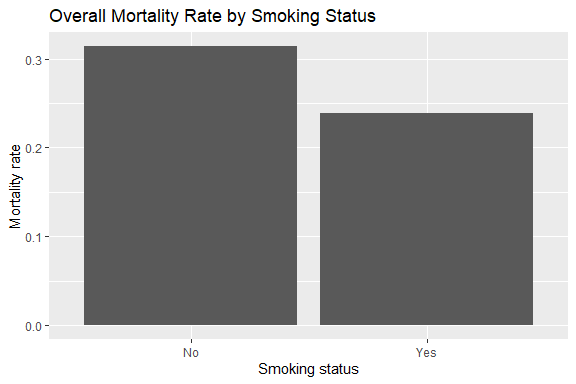

``` r
whickham_age <- Whickham %>%
  mutate(
    age_group = cut(
      age,
      breaks = c(0, 40, 50, 60, 70, Inf),
      labels = c("<40", "40-49", "50-59", "60-69", "70+"),
      right = FALSE
    )
  )


age_stratified_death_rate <- whickham_age %>%
  group_by(age_group, smoker) %>%
  summarise(
    death_rate = mean(outcome == "Dead"),
    n = n(),
    .groups = "drop"
  )

age_stratified_death_rate
```

    # A tibble: 10 × 4
       age_group smoker death_rate     n
       <fct>     <fct>       <dbl> <int>
     1 <40       No         0.0311   289
     2 <40       Yes        0.0339   236
     3 40-49     No         0.114     88
     4 40-49     Yes        0.186    118
     5 50-59     No         0.248    101
     6 50-59     Yes        0.304    112
     7 60-69     No         0.558    129
     8 60-69     Yes        0.537     82
     9 70+       No         0.912    125
    10 70+       Yes        0.912     34

``` r
ggplot(age_stratified_death_rate, aes(x = smoker, y = death_rate)) +
  geom_col() +
  facet_wrap(~ age_group) +
  labs(
    title = "Mortality Rate by Smoking Status within Age Groups",
    subtitle = "Whickham data",
    x = "Smoking status",
    y = "Mortality rate"
  )
```

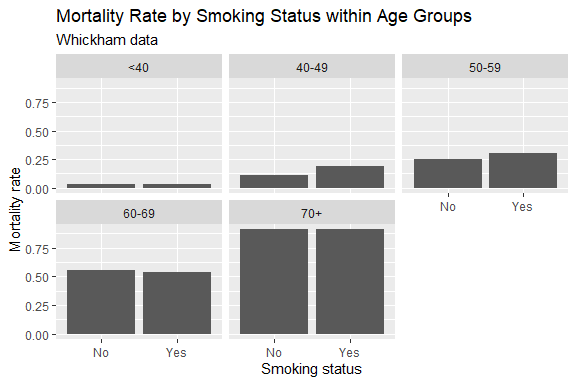

``` r
whickham_model <- Whickham %>%
  mutate(
    dead = if_else(outcome == "Dead", 1, 0),
    smoker = factor(smoker, levels = c("No", "Yes"))
  )

# 나이 보정 전: 사망 여부 ~ 흡연 여부
model_crude <- glm(
  dead ~ smoker,
  data = whickham_model,
  family = binomial()
)

summary(model_crude)
```


    Call:
    glm(formula = dead ~ smoker, family = binomial(), data = whickham_model)

    Coefficients:
                Estimate Std. Error z value Pr(>|z|)    
    (Intercept) -0.78052    0.07962  -9.803  < 2e-16 ***
    smokerYes   -0.37858    0.12566  -3.013  0.00259 ** 
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for binomial family taken to be 1)

        Null deviance: 1560.3  on 1313  degrees of freedom
    Residual deviance: 1551.1  on 1312  degrees of freedom
    AIC: 1555.1

    Number of Fisher Scoring iterations: 4

``` r
# 나이 보정 후: 사망 여부 ~ 흡연 여부 + 나이
model_adjusted <- glm(
  dead ~ smoker + age,
  data = whickham_model,
  family = binomial()
)

summary(model_adjusted)
```


    Call:
    glm(formula = dead ~ smoker + age, family = binomial(), data = whickham_model)

    Coefficients:
                 Estimate Std. Error z value Pr(>|z|)    
    (Intercept) -7.599221   0.441231 -17.223   <2e-16 ***
    smokerYes    0.204699   0.168422   1.215    0.224    
    age          0.123683   0.007177  17.233   <2e-16 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for binomial family taken to be 1)

        Null deviance: 1560.32  on 1313  degrees of freedom
    Residual deviance:  945.02  on 1311  degrees of freedom
    AIC: 951.02

    Number of Fisher Scoring iterations: 6

``` r
# 전체 자료만 보면 흡연자와 비흡연자의 사망률 관계가 왜곡되어 보일 수 있다. 
# 그 이유는 나이가 사망률에 강하게 영향을 주며, 동시에 흡연 여부와도 관련될 수 있기 때문이다. 
# 즉, 나이는 흡연 여부와 사망률 사이의 관계에서 교란변수로 작용한다.

# 나이별로 나누어 비교하거나 로지스틱 회귀에서 나이를 보정하면, 단순한 전체 비교와 다른 결론이 나올 수 있다. 
# 따라서 이 자료에서는 흡연과 사망률의 관련성을 해석할 때 반드시 나이를 보정해야 한다.
```

## Python

# 2부 데이터 분석 실무

### 스테로이드 시대 (계속)

미국 메이저리그 야구(MLB)에서 1990년대 중반에서 2000년대 초반의 기간은
선수들의 운동수행능력 향상 약물(performance-enhancing drugs, 이하 PEDs)
사용이 만연해 있던 시기로 알려져 있다. 본 과제에서는 해당 시기에 PEDs의
사용이 실제 선수들의 경기력에 영향을 미쳤다는 증거를 통계적으로 찾을 수
있는지 알아본다. 데이터는 Lahman 패키지(`Lahman` in R, `pylahman` in
Python)를 사용한다.

### 분석 관련 공통 지침

1.  관측단위(observational unit)는 `playerID`와 `yearID`의 고유한
    조합으로 한다. 즉, 데이터프레임의 각 행은 한 선수의 특정 연도에
    해당해야 하고(예: 2019년 류현진), 한 선수의 특정 연도가 두 번 이상
    나타나서는 안 된다. 이적을 한 경우 원자료에서는 두 번 이상 나타날 수
    있으므로 주의해야 한다.
2.  데이터 분석을 하는 중에 필요한 경우 pivoting으로 각 행이 한명의
    선수에 해당하는 wide format data를 만들어서 연도간 비교를 하는 것은
    허용한다.

## 문제 2-1

먼 과거 (1982-1993), 스테로이드 시대 (1994-2005), 최근 (2006-2025) 동안
타율(`BA = H/AB`로 계산)이 어떻게 다른지 비교해보자. `AB > 30`인
관측치만 사용한다.

1.  3개 기간 동안의 타율 분포를 시각화하라. 각 시기별 분포가 정규분포를
    따른다고 할 수 있는가?

2.  3개 기간 동안 평균 타율의 차이를 정규분포를 가정한 선형모형을
    이용하여 검정하라. 사용된 코딩행렬은 이들 기간의 순서가 있음을
    반영하여야 한다. 모형적합과 추론 결과에 대해 해석하라. 특히 적합된
    회귀 계수들의 값에 대한 해석, 가설검정 결과에 대한 해석, 그리고
    구간추정치 계산을 수행하여야 한다.

3.  b항과 같은 분석을 하되 정규분포를 가정한 추론이 아닌 부트스트래핑에
    의한 추론을 실시하라. 특히 적합된 회귀 계수들에 대한 구간추정치를
    계산하고 b항의 결과와 비교하라.

*답안 작성시 고려할 점*. a항에서 시각화한 각 시기별 분포를 생각할 때,
b항에서 사용한 정규분포 가정은 타당하다고 할 수 있는가? b항과 c항에서
얻은 구간추정치가 유사하다면 그 이유는 무엇인가?

### 답안

## R

## Python

## 문제 2-2

위에서 정한 각 기간에 대해서 홈런수(`HR`) 상위 1%에 해당하는 사례들만을
추출하자. (단, 상위 1%를 정할 때 `AB <= 30`인 관측치를 버리지 않는다.)
해당 사례들의 홈런수(`HR`)에 대해 문제 2-1과 같은 방식으로 분석하라.

### 답안

## R

## Python

## 문제 2-3

문제 2-2에서 추출한 관측치를 사용하여 다음 질문에 답하라.

1982년부터 2025년까지 홈런수의 분포가 어떻게 변해왔는지 시각화하고
홈런수를 반응변수로, 연도(`yearID`)를 독립변수로 하는 회귀분석을
실시하라. 연도의 효과가 거의 유의하지 않게 나온다면 분석을 올바르게 한
것이다. 타격에 대한 유력한 이론은 시간이 지날수록 홈런의 개수가 증가해
왔다는 것인데, 이 분석이 그러한 이론을 반증한다고 할 수 있는가? 아니라고
생각한다면 적절한 교락(confounding)요인을 회귀모형에 포함시켜 다시
분석을 한 뒤에 결과가 어떻게 변하는지 비교하라.

### 답안

## R

## Python

# 3부 데이터 분석 기술

숙제 1에서는 공식 GitHub 학생 개발자 팩에 가입하고 GitHub Pro 및 GitHub
Codespaces 사용을 신청했다. 여기서는 숙제 2 제출용 GitHub 저장소에
작업한 Quarto markdown 소스 파일(`hw02.qmd`)을 올리면 GitHub에서
자동으로 HTML 파일 및 주피터 노트북 파일(`.ipynb`)을 만들고 이것을
[GitHub Pages](https://docs.github.com/en/pages/quickstart)에서
웹페이지로 보이도록 설정하는 것을 연습한다.

## 문제 3-1. Quarto 프로젝트 파일 설정

로컬 저장소 최상위 디렉토리에 `_quarto.yml` 파일에 다자음 내용을
추가한다. 파일이 없다면 새로 만들어 추가한다.

In [ ]:
project:
  type: website
  output-dir: _site

format:
  html:
    embed-resources: true
  ipynb: default  # HTML 빌드 시 ipynb 파일도 함께 생성하도록 설정

`hw02.qmd`를 로컬 저장소에서 컴파일하면 `_site` 디렉토리가 생성되고 그
안에 HTML 및 수반되는 파일들이 만들어지는지 확인하라.

## 문제 3-2. GitHub Actions 워크플로우 생성

GitHub 저장소에 로컬 저장소가 push될 때마다 `.qmd` 파일 컴파일 등의
작업을 자동으로 하게 하는 일은 GitHub Actions에서 담당한다. 로컬
저장소의 `.github/workflows/` 디렉토리(없으면 만든다) 안에 `publish.yml`
파일을 아래와 같이 만든다.

In [ ]:
name: Quarto Publish (R & Custom Packages)
on:
  push:
    branches: [ main ]

jobs:
  build-deploy:
    runs-on: ubuntu-latest
    permissions:
      contents: write
    steps:
      - name: Check out repository
        uses: actions/checkout@v4

      - name: Install System Dependencies
        run: |
          sudo apt-get update

      - name: Setup Miniconda
        uses: conda-incubator/setup-miniconda@v3
        with:
          auto-update-conda: true
          python-version: '3.10'
          activate-environment: r-reticulate
          channels: conda-forge,defaults

      - name: Install Python dependencies via Conda
        run: |
          conda install -n r-reticulate numpy pandas matplotlib polars
        # 추가로 필요한 패키지 설치
        shell: bash -l {0}

      - name: Set up R
        uses: r-lib/actions/setup-r@v2
        with:
          use-public-rspm: true 

      - name: Set up Quarto
        uses: quarto-dev/quarto-actions/setup@v2

      - name: Install R Packages
        env:
          GITHUB_PAT: ${{ secrets.GITHUB_TOKEN }}
        run: |
          install.packages(c("reticulate", "knitr", "rmarkdown"))
        # 추가로 필요한 패키지 설치
        shell: Rscript {0}

      - name: Render Quarto
        run: |
          export RETICULATE_PYTHON=$(conda info --base)/envs/r-reticulate/bin/python
          quarto render
        shell: bash -l {0}

      - name: Deploy to GitHub Pages
        uses: peaceiris/actions-gh-pages@v3
        with:
          github_token: ${{ secrets.GITHUB_TOKEN }}
          publish_dir: ./_site
          publish_branch: gh-pages

추가로 `hw02.qmd` 파일을 컴파일하기 위해 필요한 R과 Python 패키지들을
“\# 추가로 필요한 패키지 설치” 부분에 기술한다.

## 문제 3-3. GitHub Pages 설정 변경

저장소를 웹페이지로 활용하는 부분은 GitHub Pages가 담당한다.

1.  문제 3-2까지의 작업을 push한 후, GitHub (원격)저장소에 `gh-pages`
    브랜치가 생성됐는지 확인하라.

2.  GitHub 저장소의 Settings \> Pages 메뉴로 이동하여 Build and
    deployment \> Branch 섹션에서 브랜치를 `gh-pages`로 선택하고 폴더를
    `/ (root)`로 설정한 뒤 저장하라.

3.  GitHub 저장소의 Actions 메뉴로 이동하여 2개의 워크플로우가 무사히
    종료되었는지 확인하라.

4.  다시 GitHub 저장소의 Settings \> Pages 메뉴로 이동하여 상단에 “Your
    site is live at https://…” 안내가 보이는지 확인하라. 이 곳의 URL이
    hw02.qmd로 생성한 웹페이지의 주소다. “Visit site” 버튼을 클릭하여
    웹페이지를 브라우저에서 볼 수 있는지 확인하라.

## 문제 3-4. 반복

Quarto 프로젝트 설정에서 주피터 노트북 파일도 함께 생성하도록
설정하였다. 웹페이지에서 노트북을 내려받을 수 있도록 하기 위해 첫
페이지를 변경하고자 한다. 이를 위해 `README.md` 파일을 로컬 저장소
최상위 디렉토리에 다음과 같이 만들자.

In [ ]:
# 숙제 2

이름: [아무개]
학번: [나의 학번]

이 숙제의 상세 분석 결과는 아래 링크에서 확인하실 수 있습니다.

* [분석 리포트 (HTML)](./hw02.html) 
* [주피터 노트북 (ipynb)](./hw02.ipynb)

이제 Quarto가 README.md를 첫 페이지로 인식하도록 하기 위해
`_quarto.yml`의 “Render Quarto” 앞에 다음을 추가하자.

In [ ]:
      - name: Prepare README as Index
        run: cp README.md index.md

작업을 GitHub 원격 저장소로 push한 후 문제 3-3의 3, 4번 과정을 반복하라.